In [15]:
!ls /content/drive/MyDrive

 AI_OilSpill				'PDF Reader (1).pdf'
'Colab Notebooks'			'PDF Reader (2).pdf'
'Document from Kalyani Patil'		'PDF Reader (3).pdf'
'Document from Kalyani Patil (1)'	'PDF Reader (4).pdf'
 IMG-20221206-WA0015.jpg		'PDF Reader (5).pdf'
'IMG-20221206-WA0016 (1).jpg'		'PDF Reader (6).pdf'
 IMG-20221206-WA0016.jpg		'PDF Reader (7).pdf'
'internship certificate 31055 (1).pdf'	'PDF Reader.pdf'
'internship certificate 31055 (2).pdf'	 Screenshot_20231129_124118_Gallery.jpg
'internship certificate 31055.pdf'	 Screenshot_20250717_121930_Drive.jpg
'Kalyani PPT.pdf'			 Screenshot_20250717_122526_YouTube.jpg
'Kalyani Report .pdf'			'Untitled Folder'
'oil spill data set'


In [19]:
!ls "/content/drive/MyDrive/oil spill data set"

 10555314.zip
 archive.zip
'CSIRO_Sentinel-1_SAR_image_dataset_of_oil-_and_non-oil_features_for_machine_learning_(_Deep_Learning_)-2YRsS0lU-.zip'
 data-10-00117-v2.pdf
 es1348.pdf
'final dataset used for oil spill'
'oil spill.lnk'


In [20]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill"

dataset-final


In [21]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final"

dataset


In [23]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset"

test  train  Validation


In [24]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train"
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/test"
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation"

'Non Oil Spill'  'Oil Spill'
'Non Oil Spill'  'Oil Spill'
'Non Oil Spill'  'Oil Spill'


In [26]:
TRAIN_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train"


In [27]:
TEST_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/test"


In [28]:
VAL_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation"


In [29]:
import os

for split, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR), ("Val", VAL_DIR)]:
    print(split, "exists:", os.path.exists(path))
    print("  Oil Spill images:", len(os.listdir(os.path.join(path, "Oil Spill"))))
    print("  Non Oil Spill images:", len(os.listdir(os.path.join(path, "Non Oil Spill"))))


Train exists: True
  Oil Spill images: 1400
  Non Oil Spill images: 1400
Test exists: True
  Oil Spill images: 300
  Non Oil Spill images: 300
Val exists: True
  Oil Spill images: 300
  Non Oil Spill images: 300


In [30]:
data = []

for split, path in [("train", TRAIN_DIR), ("test", TEST_DIR), ("val", VAL_DIR)]:
    for label in ["Oil Spill", "Non Oil Spill"]:
        count = len(os.listdir(os.path.join(path, label)))
        data.append({
            "split": split,
            "class": label,
            "count": count
        })

import pandas as pd
df = pd.DataFrame(data)
df


,split,class,count
0,train,Oil Spill,1400
1,train,Non Oil Spill,1400
2,test,Oil Spill,300
3,test,Non Oil Spill,300
4,val,Oil Spill,300
5,val,Non Oil Spill,300


from matplotlib import pyplot as plt
df['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('split').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('class').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['class'].value_counts()
    for x_label, grp in df.groupby('split')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('split')
_ = plt.ylabel('class')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['split'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='count', y='split', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['class'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='count', y='class', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

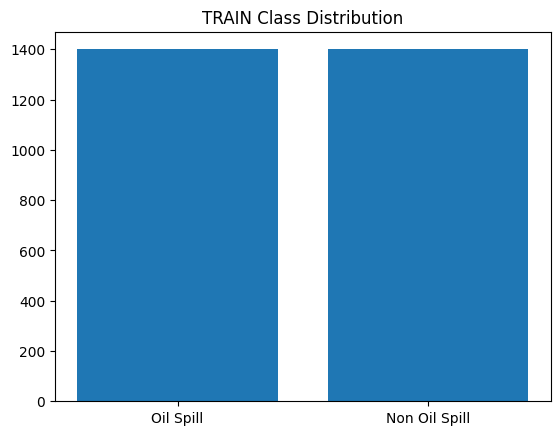

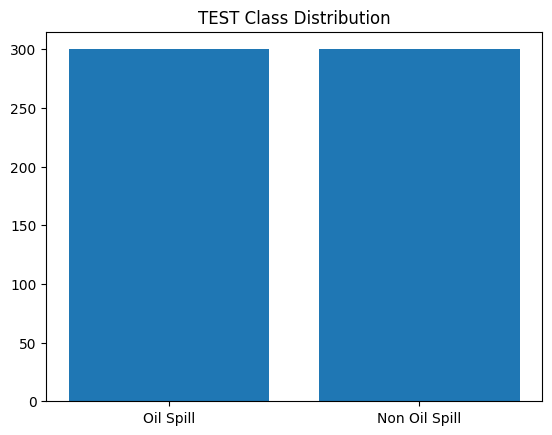

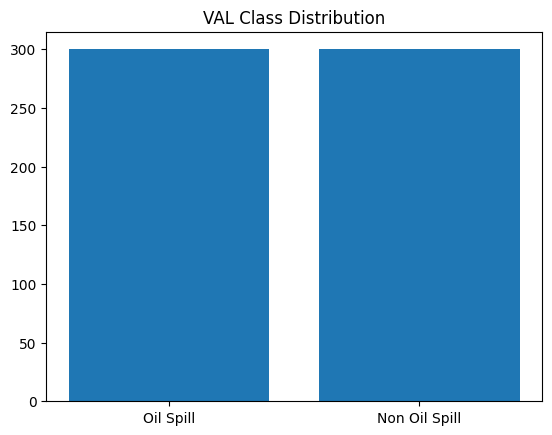

In [31]:
import matplotlib.pyplot as plt

for split in df["split"].unique():
    sub = df[df["split"] == split]
    plt.bar(sub["class"], sub["count"])
    plt.title(f"{split.upper()} Class Distribution")
    plt.show()


In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


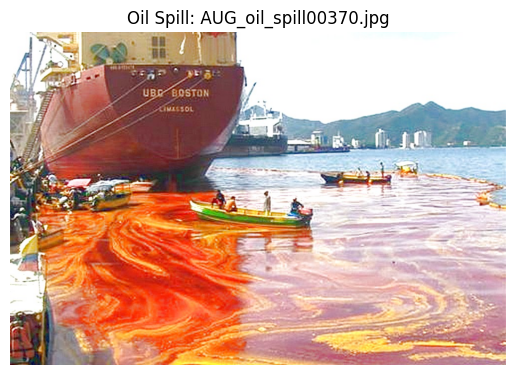

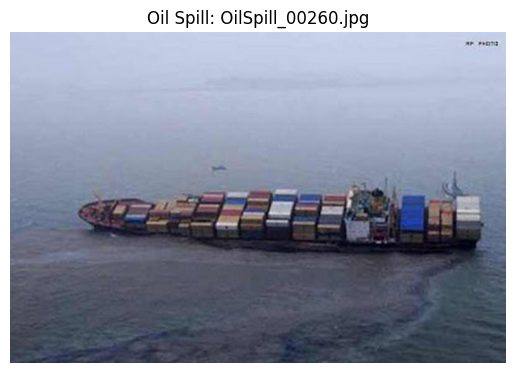

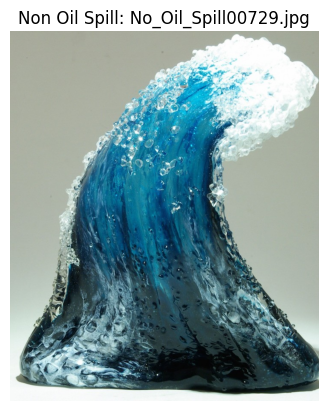

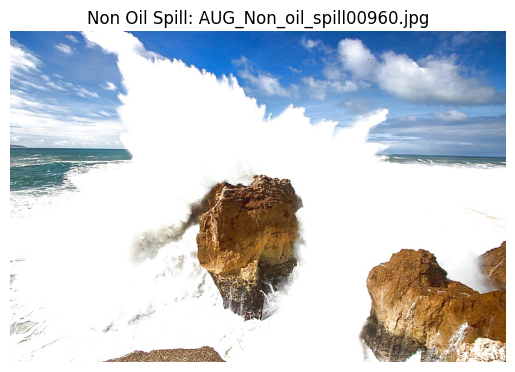

In [33]:
import random

# Pick 2 random images from each class in train
for label in ["Oil Spill", "Non Oil Spill"]:
    files = os.listdir(os.path.join(TRAIN_DIR, label))
    sample_files = random.sample(files, 2)

    for f in sample_files:
        img_path = os.path.join(TRAIN_DIR, label, f)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(f"{label}: {f}")
        plt.axis('off')
        plt.show()


In [34]:
TARGET_SIZE = (256, 256)  # resize all images to 256x256

def preprocess_image(img):
    img = cv2.resize(img, TARGET_SIZE)
    img = img / 255.0  # normalize to 0-1
    return img

def load_images_from_folder(folder):
    images = []
    for f in os.listdir(folder):
        img_path = os.path.join(folder, f)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_image(img)
        images.append(img)
    return np.array(images)


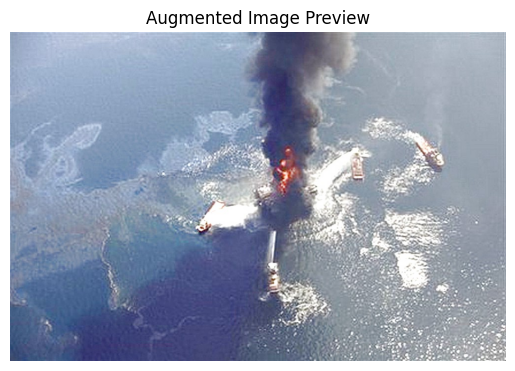

In [35]:
!pip install -q albumentations

import albumentations as A

# Simple augmentation: horizontal flip + brightness
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

# Preview on one image
sample_img_path = os.path.join(TRAIN_DIR, "Oil Spill", os.listdir(os.path.join(TRAIN_DIR, "Oil Spill"))[0])
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

aug = transform(image=img)
plt.imshow(aug['image'])
plt.title("Augmented Image Preview")
plt.axis('off')
plt.show()


In [36]:
import torch
from torch.utils.data import Dataset, DataLoader

class OilSpillDataset(Dataset):
    def __init__(self, root_dir, classes=["Oil Spill", "Non Oil Spill"], transform=None):
        self.samples = []
        for label, class_name in enumerate(classes):
            folder = os.path.join(root_dir, class_name)
            for f in os.listdir(folder):
                self.samples.append((os.path.join(folder, f), label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        img = img / 255.0
        img = np.transpose(img, (2,0,1))  # HWC -> CHW
        if self.transform:
            img = self.transform(image=img)['image']
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Test
train_dataset = OilSpillDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

for imgs, labels in train_loader:
    print("Batch image shape:", imgs.shape)
    print("Batch labels:", labels)
    break


Batch image shape: torch.Size([4, 3, 256, 256])
Batch labels: tensor([1, 1, 1, 0])
